<a href="https://colab.research.google.com/github/Pradeep-Kumar-Panga/DecodingComplexities/blob/main/CrossEntropy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cross Entropy
Every tutorial tells you the same thing: If you are classifying an image (like Cats vs. Dogs), you MUST use Cross-Entropy Loss instead of Mean Squared Error (MSE).

But... why? What actually happens to a Neural Network if you use MSE for classification?

In this Applied Engineering Lab, we decode the math behind loss functions. We prove visually why MSE causes models to get "stuck," and why Cross-Entropy acts as a massive penalty that forces a network to learn quickly.

Run through the code in this notebook to findout.

For a visual explanation, consider viewing this video: https://youtu.be/AOXiZ-gw_WI

If you prefer reading, here is the companion blog post: https://www.pradeeppanga.com/2026/03/cross-entropy.html


### 1. Setup and Libraries
We begin by importing `numpy` for calculations, and `matplotlib` and `seaborn` to create professional, high-contrast visualizations.

In [ ]:
# Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for professional, high-contrast plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 2. Visualizing Entropy
This cell calculates and plots the entropy of a coin flip to demonstrate how uncertainty (chaos) reaches its maximum when the probability is exactly 0.5.

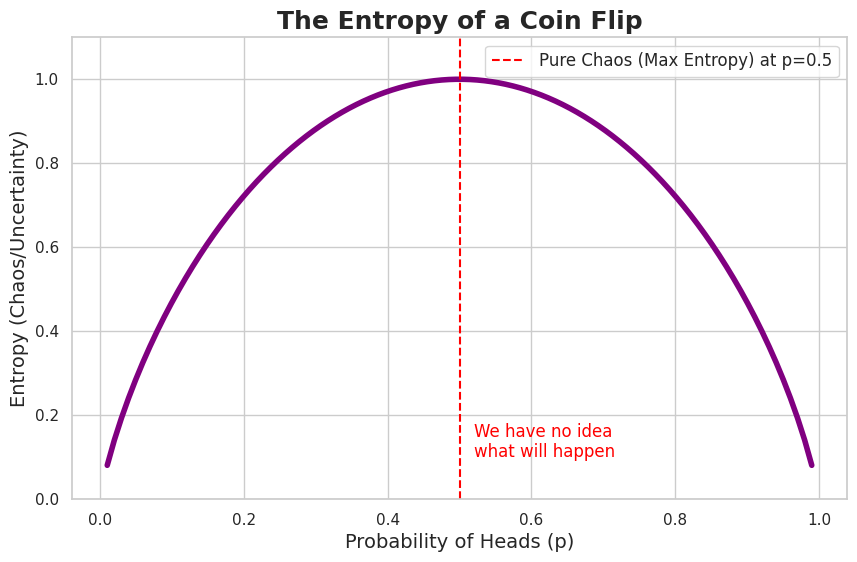

In [ ]:
# Probability of Heads (p) ranging from 1% to 99%
# We avoid exactly 0 and 1 here just to prevent log(0) warnings in the pure math
p_heads = np.linspace(0.01, 0.99, 100)
p_tails = 1 - p_heads

# Entropy Formula: Weighted average of surprise
# H = -[P(heads)*log2(P(heads)) + P(tails)*log2(P(tails))]
entropy = -(p_heads * np.log2(p_heads)) - (p_tails * np.log2(p_tails))

# Plot the Entropy Curve
plt.figure()
plt.plot(p_heads, entropy, color='purple', linewidth=4)

# Annotations for the video
plt.axvline(0.5, color='red', linestyle='--', label="Pure Chaos (Max Entropy) at p=0.5")
plt.text(0.52, 0.1, "We have no idea\nwhat will happen", color='red', fontsize=12)

plt.title("The Entropy of a Coin Flip", fontsize=18, fontweight='bold')
plt.xlabel("Probability of Heads (p)", fontsize=14)
plt.ylabel("Entropy (Chaos/Uncertainty)", fontsize=14)
plt.ylim(0, 1.1)
plt.legend(fontsize=12)
plt.show()

### 3. MSE vs. Cross-Entropy
Here we compare Mean Squared Error and Binary Cross-Entropy. Notice how Cross-Entropy penalizes wrong guesses much more aggressively than MSE.

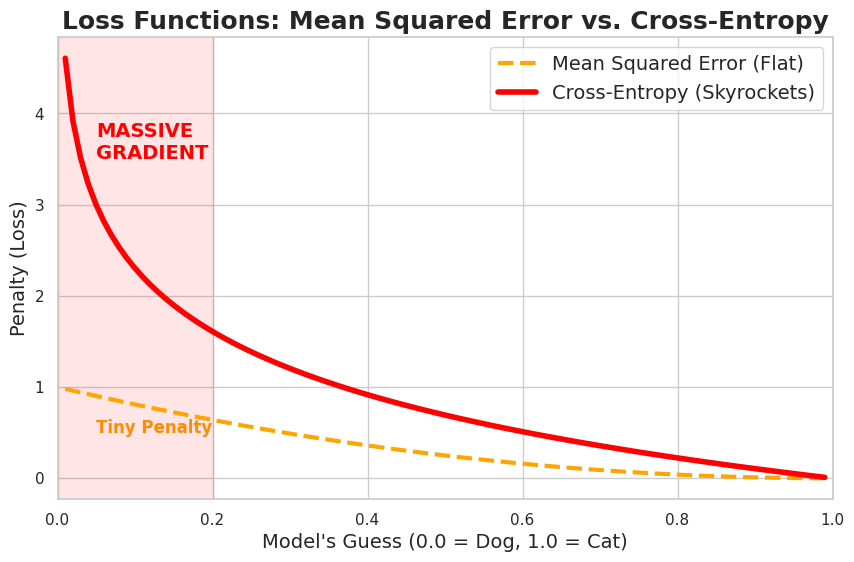

In [ ]:
# Scenario: Image is a Cat. The TRUTH is 1.
truth = 1.0

# Model predicts anywhere from 1% confident to 99% confident
guess = np.linspace(0.01, 0.99, 100)

# 1. Mean Squared Error: (Actual - Predicted)^2
mse_loss = (truth - guess)**2

# 2. Binary Cross-Entropy: -[Truth * log(Guess) + (1-Truth) * log(1-Guess)]
# Since Truth = 1, the second half cancels out to 0. We are left with:
bce_loss = -truth * np.log(guess)

# Plot Both Curves Side-by-Side
plt.figure()

# Plot MSE (The weak slap on the wrist)
plt.plot(guess, mse_loss, color='orange', linestyle='--', linewidth=3, label="Mean Squared Error (Flat)")

# Plot BCE (The massive gradient)
plt.plot(guess, bce_loss, color='red', linewidth=4, label="Cross-Entropy (Skyrockets)")

plt.title("Loss Functions: Mean Squared Error vs. Cross-Entropy", fontsize=18, fontweight='bold')
plt.xlabel("Model's Guess (0.0 = Dog, 1.0 = Cat)", fontsize=14)
plt.ylabel("Penalty (Loss)", fontsize=14)

# Highlight the problem area where the model is WRONG (guess near 0.0)
plt.axvspan(0.0, 0.2, color='red', alpha=0.1)
plt.text(0.05, 3.5, "MASSIVE\nGRADIENT", color='red', fontsize=14, fontweight='bold')
plt.text(0.05, 0.5, "Tiny Penalty", color='darkorange', fontsize=12, fontweight='bold')

plt.xlim(0, 1)
plt.legend(fontsize=14)
plt.show()

### 4. Implementing Binary Cross-Entropy
We define two versions of the BCE function: a 'naive' version that can crash with log(0) and a 'safe' version that uses clipping to prevent numerical errors.

In [ ]:
def naive_bce(y_true, y_pred):
    """The raw mathematical formula (Dangerous)"""
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def safe_bce(y_true, y_pred):
    """Build Safety Buffer"""
    epsilon = 1e-10  # 0.0000000001

    # np.clip forces the guess to stay between epsilon and (1 - epsilon)
    # It can never be exactly 0.0 or 1.0
    safe_guess = np.clip(y_pred, epsilon, 1.0 - epsilon)

    return -(y_true * np.log(safe_guess) + (1 - y_true) * np.log(1 - safe_guess))

print("Testing the model when it is 100% confidently WRONG (Prediction = 0.0):")

Testing the model when it is 100% confidently WRONG (Prediction = 0.0):


### 5. The Mathematical Crash
This cell demonstrates what happens when the naive math encounters a 0% probability prediction, resulting in an infinite loss or a runtime warning.

In [ ]:
# 1. The Crash
print("\n1. Running Naive Math:")
try:
    bad_loss = naive_bce(y_true=1.0, y_pred=0.0)
    print(f"Result: {bad_loss}")
except Exception as e:
    print(f"Crash! Error: {e}")


1. Running Naive Math:
Result: inf


/tmp/ipykernel_591/3774094786.py:3: RuntimeWarning: divide by zero encountered in log
  return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


### 6. The Engineering Fix
Finally, we run the safe version of the function, which uses `np.clip` to ensure the code remains stable and returns a large finite penalty instead of crashing.

In [ ]:
# 2. The Fix
print("\n2. Running Safe Math (with np.clip):")
good_loss = safe_bce(y_true=1.0, y_pred=0.0)
print(f"Result: {good_loss:.2f}")
print("Server survives! The model gets a massive penalty instead of a NaN crash.")


2. Running Safe Math (with np.clip):
Result: 23.03
Server survives! The model gets a massive penalty instead of a NaN crash.
